In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Поднимаемся в корень проекта
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

print('Текущая папка:', os.getcwd())

# Настройка графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Готово')

Текущая папка: /Users/vestochka/sberindex-clustering
Готово


In [2]:
infra = pd.read_parquet('data/processed/infrastructure.parquet')

print('Размер:', infra.shape)
print()
print('Столбцы:')
for col in infra.columns:
    print(f'  {col}')
print()
print('Первые 3 строки:')
infra.head(3)

Размер: (2603, 14)

Столбцы:
  oktmo_stable
  region_name
  area_ha
  gas_network_m
  invest_budget
  invest_org
  living_area
  n_beneficiaries
  n_families_subsidies
  n_kindergarten
  n_no_gas_settlements
  roads_km
  subsidies_rub
  water_network_m

Первые 3 строки:


,oktmo_stable,region_name,area_ha,gas_network_m,invest_budget,invest_org,living_area,n_beneficiaries,n_families_subsidies,n_kindergarten,n_no_gas_settlements,roads_km,subsidies_rub,water_network_m
0,01512000,Алтайский край,327456.0,NaN,4747.0,17901.692308,327.54,2505.750,172.125,104.272727,22.0,244.000000,2951.4000,171000.0
1,01514000,Алтайский край,280161.0,NaN,2507.0,614742.333333,492.43,3678.125,644.375,167.857143,24.0,429.533333,16005.0000,213050.0
2,01539000,Алтайский край,213661.0,NaN,10513.0,47726.133333,960.66,7163.625,1990.875,342.750000,23.0,452.333333,54137.1375,121000.0


In [3]:
# Считаем пропуски
missing = infra.isnull().sum()
missing_pct = (missing / len(infra) * 100).round(1)

# Собираем в таблицу
missing_table = pd.DataFrame({
    'пропусков': missing,
    'процент': missing_pct
}).sort_values('процент', ascending=False)

# Добавляем категорию
def categorize(pct):
    if pct == 0:
        return '✅ нет'
    elif pct < 10:
        return '🟢 <10%'
    elif pct < 30:
        return '🟡 10-30%'
    else:
        return '🔴 >30%'

missing_table['статус'] = missing_table['процент'].apply(categorize)

print('Пропуски по признакам (без идентификаторов):')
print(missing_table.drop(['oktmo_stable', 'region_name']).to_string())
print()
print(f'Всего МО: {len(infra)}')
print(f'Признаков: {len(infra.columns) - 2}')

Пропуски по признакам (без идентификаторов):
                      пропусков  процент    статус
gas_network_m               921     35.4    🔴 >30%
n_no_gas_settlements        743     28.5  🟡 10-30%
invest_budget               653     25.1  🟡 10-30%
n_families_subsidies        525     20.2  🟡 10-30%
subsidies_rub               524     20.1  🟡 10-30%
n_beneficiaries             431     16.6  🟡 10-30%
water_network_m             426     16.4  🟡 10-30%
roads_km                    291     11.2  🟡 10-30%
living_area                 280     10.8  🟡 10-30%
n_kindergarten              195      7.5    🟢 <10%
invest_org                  190      7.3    🟢 <10%
area_ha                     165      6.3    🟢 <10%

Всего МО: 2603
Признаков: 12


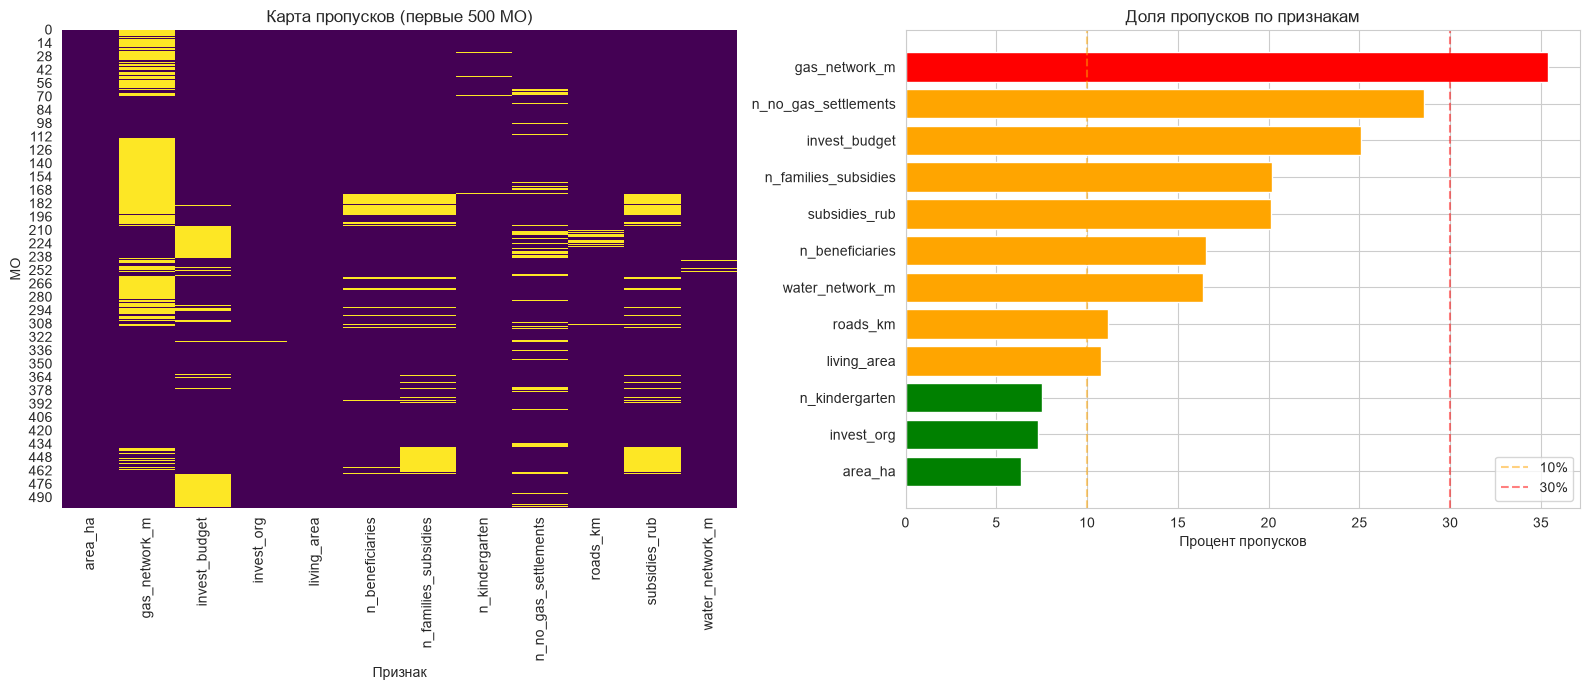

Сохранено: results/eda/missing_values.png


In [4]:
features = [c for c in infra.columns if c not in ['oktmo_stable', 'region_name']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Теплокарта пропусков (первые 500 строк)
sample = infra[features].iloc[:500]
sns.heatmap(sample.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Карта пропусков (первые 500 МО)')
axes[0].set_xlabel('Признак')
axes[0].set_ylabel('МО')

# 2. Гистограмма пропусков
missing_pct = (infra[features].isnull().mean() * 100).sort_values(ascending=True)
colors = ['green' if x < 10 else 'orange' if x < 30 else 'red' for x in missing_pct]

axes[1].barh(missing_pct.index, missing_pct.values, color=colors)
axes[1].set_xlabel('Процент пропусков')
axes[1].set_title('Доля пропусков по признакам')
axes[1].axvline(10, color='orange', linestyle='--', alpha=0.5, label='10%')
axes[1].axvline(30, color='red', linestyle='--', alpha=0.5, label='30%')
axes[1].legend()

plt.tight_layout()
Path('results/eda').mkdir(parents=True, exist_ok=True)
plt.savefig('results/eda/missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/missing_values.png')

In [5]:
# Топ-15 регионов по суммарным пропускам
infra['n_missing'] = infra[features].isnull().sum(axis=1)

top_missing = (
    infra.groupby('region_name')['n_missing']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(15)
)
top_missing.columns = ['всего пропусков', 'в среднем на МО', 'число МО']

print('ТОП-15 регионов по пропускам:')
print(top_missing.to_string())
print()

# Разбор по конкретным признакам для топ-3 регионов
top3_regions = top_missing.index[:3].tolist()
print(f'Разбор по топ-3 регионам: {top3_regions}')
print()

for region in top3_regions:
    sub = infra[infra['region_name'] == region]
    print(f'{region} (МО: {len(sub)}):')
    missing_pct = (sub[features].isnull().mean() * 100).round(0).sort_values(ascending=False)
    print(missing_pct[missing_pct > 0].to_string())
    print()

ТОП-15 регионов по пропускам:
                       всего пропусков  в среднем на МО  число МО
region_name                                                      
Москва                            1205         8.253425       146
Санкт-Петербург                   1009         9.008929       112
Новосибирская область              245         7.000000        35
Рязанская область                  238         7.933333        30
Тверская область                   232         6.105263        38
Кемеровская область                231         7.000000        33
Республика Дагестан                159         3.057692        52
Приморский край                    120         3.428571        35
Московская область                 120         2.068966        58
Республика Карелия                  83         4.611111        18
Севастополь                         82         8.200000        10
Республика Бурятия                  79         3.434783        23
Вологодская область                 75        

Анализ пропусков показал, что основной источник пропусков — внутригородские территории Москвы и Санкт-Петербурга (258 МО, 12% датасета). Данные по ним в БД ПМО не собираются, поскольку статистика ведётся по городу в целом. Для остальных регионов пропуски составляют 3–10% и связаны с отсутствием отчётности по отдельным показателям.

Стратегия обработки пропусков:

Для Москвы и СПб — пометка is_metropolitan и исключение из кластеризации (или отдельный анализ).

Для газа и негазифицированных пунктов — логические нули (нет данных = нет инфраструктуры).

Для остальных признаков — медианная импутация по региону.

Для Новосибирской области (аномальные 100% пропусков по 7 признакам) — импутация глобальной медианой + флаг.

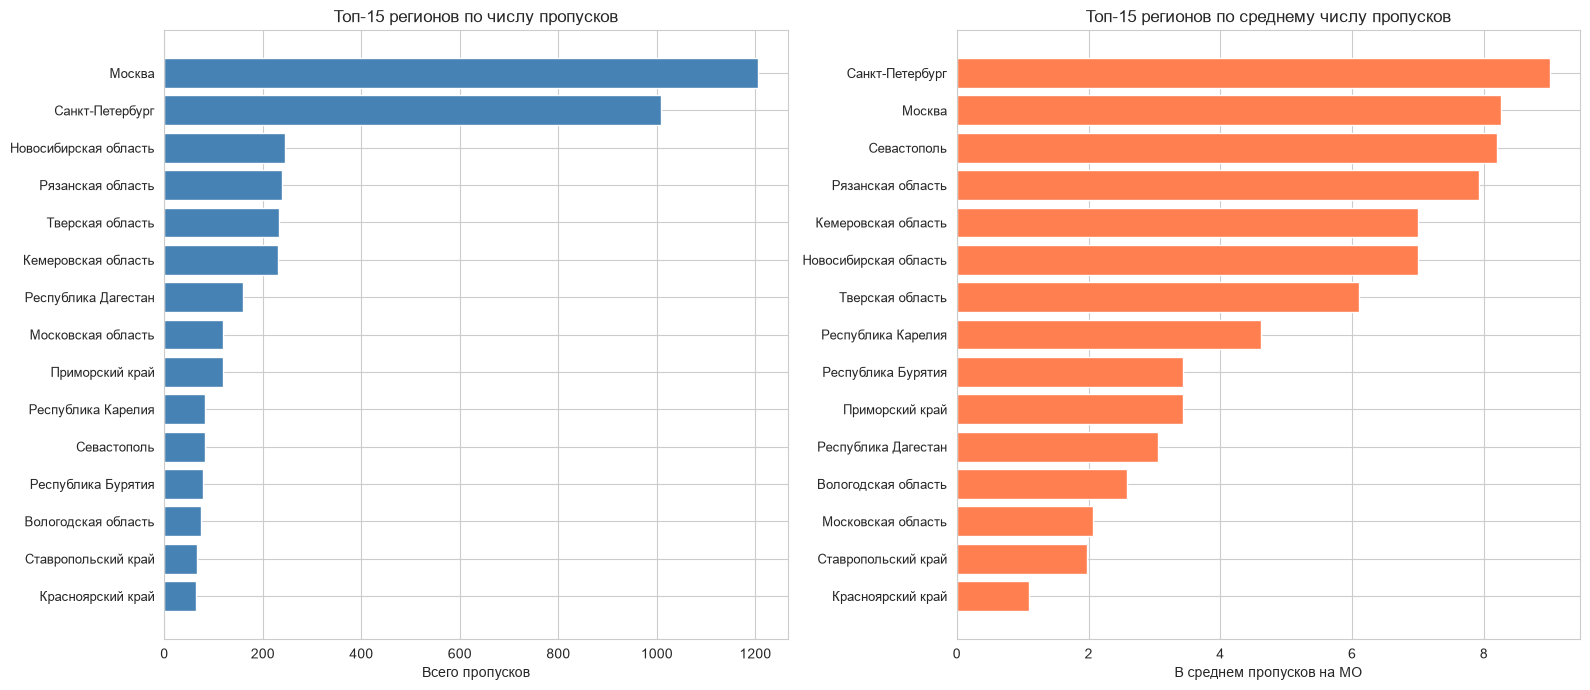

Сохранено: results/eda/missing_by_region.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Топ-15 регионов по общему числу пропусков
top15 = top_missing.head(15).sort_values('сумма' if 'сумма' in top_missing.columns else 'всего пропусков')

# Используем правильное имя столбца
col_sum = [c for c in top_missing.columns if 'всего' in c or 'сумма' in c][0]
col_mean = [c for c in top_missing.columns if 'средн' in c][0]

top15 = top_missing.head(15).sort_values(col_sum)
axes[0].barh(top15.index, top15[col_sum], color='steelblue')
axes[0].set_xlabel('Всего пропусков')
axes[0].set_title('Топ-15 регионов по числу пропусков')
axes[0].tick_params(axis='y', labelsize=9)

# 2. Топ-15 регионов по среднему числу пропусков на МО
top15_mean = top_missing.head(15).sort_values(col_mean)
axes[1].barh(top15_mean.index, top15_mean[col_mean], color='coral')
axes[1].set_xlabel('В среднем пропусков на МО')
axes[1].set_title('Топ-15 регионов по среднему числу пропусков')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('results/eda/missing_by_region.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/missing_by_region.png')